In [4]:
#####################################################################################################################################
##### STEP 3: Build final integrated PKN combining metabolite-gene and PPI networks
#####
##### This script combines the PPI and metabolite-gene PKNs into a final integrated network.
#####
##### WORKFLOW:
#####   1. Run: Collect_PKNdata_metabolites.ipynb  (outputs: metabolite_gene_PKN.tsv)
#####   2. Run: Collect_PKNdata_proteins.ipynb     (outputs: PPI_network.tsv)  
#####   3. Run: Build_final_PKN.ipynb              (this script - combines both networks)
#####
##### IMPORTANT: Make sure OUTPUT_DIR_NAME matches the one used in the previous two scripts
#####################################################################################################################################

In [5]:
import os
import pandas as pd
import numpy as np
import networkx as nx

# ===== CONFIGURATION - Change output directory here =====
# This should match the OUTPUT_DIR_NAME used in the previous two scripts
workdir = '/home/borisvdm/Documents/PhD/Lemonite'
OUTPUT_DIR_NAME = 'PKN251013ed'  # Change this to match the other scripts
# ========================================================

# Set up paths
OUTPUT_DIR = os.path.join(workdir, OUTPUT_DIR_NAME)
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')

# Input files (outputs from previous scripts)
PPI_NETWORK_FILE = os.path.join(OUTPUT_DIR, 'PPI_network.tsv')
METABOLITE_GENE_PKN_FILE = os.path.join(OUTPUT_DIR, 'metabolite_gene_PKN.tsv')
ANNOTATED_METS_FILE = os.path.join(OUTPUT_DIR, 'HMDB_metabolites_annotated.csv')

# Link files (generated by metabolites script)
INTACT_LINKS_FILE = os.path.join(OUTPUT_DIR, 'HMDB_metabolites_annotated_IntAct_links.csv')
STITCH_LINKS_FILE = os.path.join(OUTPUT_DIR, 'HMDB_metabolites_annotated_STITCH_links.csv')
BIOGRID_LINKS_FILE = os.path.join(OUTPUT_DIR, 'HMDB_metabolites_annotated_BioGRID_links.csv')
UNIPROT_LINKS_FILE = os.path.join(OUTPUT_DIR, 'HMDB_metabolites_annotated_UniProtKB_links.csv')
CHEMBL_LINKS_FILE = os.path.join(OUTPUT_DIR, 'HMDB_metabolites_annotated_chEMBL_links.csv')

# Output files
FINAL_PKN_FILE = os.path.join(OUTPUT_DIR, 'LemonIte_PKN.tsv')
FINAL_PKN_WITH_LINKS_FILE = os.path.join(OUTPUT_DIR, 'LemonIte_PKN_with_links.tsv')

# Figure files
COMPARISON_FIGURE = os.path.join(FIGURES_DIR, 'number_of_metabolites_genes_interactions_per_database.png')
SUPERCLASS_HEATMAP_FIGURE = os.path.join(FIGURES_DIR, 'percentage_of_metabolites_in_each_superclass_per_database.png')

# External database locations (for comparison analysis)
METALINKS_DB = '/home/borisvdm/Documents/PhD/resources/databases/metalinks/metalinks.csv'
MEBOCOST_DB = '/home/borisvdm/Documents/PhD/resources/databases/MEBOCOST/metabolite_associated_gene_reaction_HMDB_summary.tsv'

# Create output directories if they don't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"Configuration:")
print(f"  Working directory: {workdir}")
print(f"  Output directory: {OUTPUT_DIR}")
print(f"  Input PPI network: {PPI_NETWORK_FILE}")
print(f"  Input metabolite-gene PKN: {METABOLITE_GENE_PKN_FILE}")
print(f"  Output final PKN: {FINAL_PKN_FILE}")

Configuration:
  Working directory: /home/borisvdm/Documents/PhD/Lemonite
  Output directory: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed
  Input PPI network: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/PPI_network.tsv
  Input metabolite-gene PKN: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/metabolite_gene_PKN.tsv
  Output final PKN: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/LemonIte_PKN.tsv


In [6]:
print(f"Reading metabolite-gene PKN from: {METABOLITE_GENE_PKN_FILE}")
metabolite_gene_network = pd.read_csv(METABOLITE_GENE_PKN_FILE, sep='\t')
print(metabolite_gene_network)
metabolites = metabolite_gene_network['Metabolite'].unique()
print(f'Number of metabolites in the metabolite-gene PKN: {len(list(set(metabolites)))}')

genes_in_metabolite_gene_PKN = metabolite_gene_network['Gene'].unique()
print(f'Number of genes in the metabolite-gene PKN: {len(list(set(genes_in_metabolite_gene_PKN)))}')

Reading metabolite-gene PKN from: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/metabolite_gene_PKN.tsv
                              Metabolite      Gene            Source
0          1-Methylhistidine_HMDB0000001     ACTA1           BioGRID
1         1,3-Diaminopropane_HMDB0000002      DHPS         UniProtKB
2         1,3-Diaminopropane_HMDB0000002        DS         UniProtKB
3         1,3-Diaminopropane_HMDB0000002      AOC1  Human1_GEM_dist1
4         1,3-Diaminopropane_HMDB0000002      AOC2  Human1_GEM_dist1
...                                  ...       ...               ...
405656  Glycerol 1-myristate_HMDB0304951    MOGAT2         UniProtKB
405657  Glycerol 1-myristate_HMDB0304951       DC5         UniProtKB
405658  Glycerol 1-myristate_HMDB0304951   DGAT2L5         UniProtKB
405659  Glycerol 1-myristate_HMDB0304951    ABHD12         UniProtKB
405660  Glycerol 1-myristate_HMDB0304951  C20orf22         UniProtKB

[405661 rows x 3 columns]
Number of metabolites in the metaboli

In [7]:
metabolite_gene_network_NoSource = metabolite_gene_network.drop(columns=['Source'])
# drop duplicates
metabolite_gene_network_NoSource = metabolite_gene_network_NoSource.drop_duplicates()
print(f'There are {metabolite_gene_network_NoSource.shape[0]} unique edges in the metabolite-gene PKN')

There are 371270 unique edges in the metabolite-gene PKN


In [8]:
print(f"Reading PPI network from: {PPI_NETWORK_FILE}")
PPI_network = pd.read_csv(PPI_NETWORK_FILE, sep='\t')
PPI_network
print(f'There are {PPI_network.shape[0]} edges in the PPI network')
print(f"There are {PPI_network.drop(columns = ['Source']).drop_duplicates().shape[0]} unique edges in the PPI network")
print(PPI_network)
# How many nodes are in the PPI network?
PPI_nodes = set(PPI_network['GeneA']).union(set(PPI_network['GeneB']))
print(f'There are {len(PPI_nodes)} nodes in the PPI network')

Reading PPI network from: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/PPI_network.tsv
There are 2778348 edges in the PPI network
There are 2778348 edges in the PPI network
There are 2318775 unique edges in the PPI network
             GeneA            GeneB  combined_score  Source
0          CYP26B1          ALDH1A2           0.981  STRING
1          CYP26B1          ALDH1A3           0.975  STRING
2          CYP26B1          ALDH1A1           0.962  STRING
3          CYP26B1           CRABP1           0.958  STRING
4          CYP26B1           CYP2B6           0.935  STRING
...            ...              ...             ...     ...
2778343     MRPL12          EXOC3L2             NaN    HuRI
2778344  NOTCH2NLA           MYO15B             NaN    HuRI
2778345     SEC22B  TM4SF19-DYNLT2B             NaN    HuRI
2778346       CCL4             MRM1             NaN    HuRI
2778347     CCL4L2             MRM1             NaN    HuRI

[2778348 rows x 4 columns]
There are 28017 nodes in

In [9]:
# drop combined_score column
PPI_network = PPI_network.drop(columns=['combined_score'])
metabolite_gene_network.columns = ['Node1', 'Node2', 'Source']
PPI_network.columns = ['Node1', 'Node2','Source']
# Add column Type with value 'PPI' to PPI_network
PPI_network['Type'] = 'PPI'
# Add column Type with value 'metabolite_gene' to metabolite_gene_network
metabolite_gene_network['Type'] = 'metabolite-gene'
# Paste the networks underneath each other
combined_network = pd.concat([PPI_network, metabolite_gene_network], axis=0)
print('Combined network:')
print(combined_network.head())
print(combined_network.tail())
print(f'The combined network has {combined_network.shape[0]} edges')

Combined network:
     Node1    Node2  Source Type
0  CYP26B1  ALDH1A2  STRING  PPI
1  CYP26B1  ALDH1A3  STRING  PPI
2  CYP26B1  ALDH1A1  STRING  PPI
3  CYP26B1   CRABP1  STRING  PPI
4  CYP26B1   CYP2B6  STRING  PPI
                                   Node1     Node2     Source             Type
405656  Glycerol 1-myristate_HMDB0304951    MOGAT2  UniProtKB  metabolite-gene
405657  Glycerol 1-myristate_HMDB0304951       DC5  UniProtKB  metabolite-gene
405658  Glycerol 1-myristate_HMDB0304951   DGAT2L5  UniProtKB  metabolite-gene
405659  Glycerol 1-myristate_HMDB0304951    ABHD12  UniProtKB  metabolite-gene
405660  Glycerol 1-myristate_HMDB0304951  C20orf22  UniProtKB  metabolite-gene
The combined network has 3184009 edges


In [10]:
# Remove duplicates, don't care about the source
combined_network_pruned = combined_network.drop_duplicates(subset=['Node1', 'Node2'])
# How many unique interactions in this combined network?
print('Unique interactions in the combined network:', combined_network_pruned.shape[0])
# Save the combined network
combined_network_pruned.to_csv(FINAL_PKN_FILE, sep='\t', index=False, header=True)
print(f'Saved final PKN to: {FINAL_PKN_FILE}')

Unique interactions in the combined network: 2558081
Saved final PKN to: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/LemonIte_PKN.tsv
Saved final PKN to: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/LemonIte_PKN.tsv


In [11]:
# how many metabolite-gene interactions?
metabolite_gene_interactions = combined_network_pruned[combined_network_pruned['Type'] == 'metabolite-gene']
print(f'There are {metabolite_gene_interactions.shape[0]} unique metabolite-gene interactions in the combined network')

# how many PPI
PPI_interactions = combined_network_pruned[combined_network_pruned['Type'] == 'PPI']
print(f'There are {PPI_interactions.shape[0]} unique PPI interactions in the combined network')
# how many PPI not considering Source?
PPI_interactions_NoSource = PPI_interactions.drop(columns=['Source'])
PPI_interactions_NoSource = PPI_interactions_NoSource.drop_duplicates()
print(f'There are {PPI_interactions_NoSource.shape[0]} unique PPI interactions in the combined network when not considering Source')

There are 371270 unique metabolite-gene interactions in the combined network
There are 2186811 unique PPI interactions in the combined network
There are 2186811 unique PPI interactions in the combined network
There are 2186811 unique PPI interactions in the combined network when not considering Source
There are 2186811 unique PPI interactions in the combined network when not considering Source


# Add link to interactions for metabolite-gene interactions

In [12]:
print("Reading interaction link files...")
intact = pd.read_csv(INTACT_LINKS_FILE, sep='\t')
stitch = pd.read_csv(STITCH_LINKS_FILE, sep='\t')
biogrid = pd.read_csv(BIOGRID_LINKS_FILE, sep='\t')
uniprot = pd.read_csv(UNIPROT_LINKS_FILE, sep='\t')
chembl = pd.read_csv(CHEMBL_LINKS_FILE, sep='\t')
print("Link files loaded successfully")

Reading interaction link files...
Link files loaded successfully


In [13]:
tmp = combined_network_pruned.copy()
# on tmp, split Node1 on _ and only keep the last part
tmp['Node1'] = tmp['Node1'].str.split('_').str[-1]
tmp
# select network with only Type == metabolite-gene
tmp = tmp[tmp['Type'] == 'metabolite-gene']
tmp
# initiate empty column link
tmp['link'] = np.nan
tmp

,Node1,Node2,Source,Type,link
0,HMDB0000001,ACTA1,BioGRID,metabolite-gene,NaN
1,HMDB0000002,DHPS,UniProtKB,metabolite-gene,NaN
2,HMDB0000002,DS,UniProtKB,metabolite-gene,NaN
3,HMDB0000002,AOC1,Human1_GEM_dist1,metabolite-gene,NaN
4,HMDB0000002,AOC2,Human1_GEM_dist1,metabolite-gene,NaN
...,...,...,...,...,...
405656,HMDB0304951,MOGAT2,UniProtKB,metabolite-gene,NaN
405657,HMDB0304951,DC5,UniProtKB,metabolite-gene,NaN
405658,HMDB0304951,DGAT2L5,UniProtKB,metabolite-gene,NaN
405659,HMDB0304951,ABHD12,UniProtKB,metabolite-gene,NaN


In [15]:
print(f"Reading annotated metabolites from: {ANNOTATED_METS_FILE}")
annotated_mets = pd.read_csv(ANNOTATED_METS_FILE, sep='\t')
annotated_mets

Reading annotated metabolites from: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/HMDB_metabolites_annotated.csv


,Name,HMDB,ChEBI,KEGG,PubChem,IUPAC_Name,SMILES,InChIKey,PDB_ID,Kingdom,Super_Class,Sub_Class,Canonical_smiles
0,1-Methylhistidine,HMDB0000001,50599.0,C01152,92105.0,(2S)-2-amino-3-(1-methyl-1H-imidazol-4-yl)prop...,CN1C=NC(C[C@H](N)C(O)=O)=C1,BRMWTNUJHUMWMS-LURJTMIESA-N,NaN,Organic acids and derivatives,Organic acids and derivatives,"Amino acids, peptides, and analogues",Cn1cnc(C[C@H](N)C(=O)O)c1
1,"1,3-Diaminopropane",HMDB0000002,15725.0,C00986,428.0,"propane-1,3-diamine",NCCCN,XFNJVJPLKCPIBV-UHFFFAOYSA-N,NaN,Organic nitrogen compounds,Organic nitrogen compounds,Amines,NCCCN
2,2-Ketobutyric acid,HMDB0000005,30831.0,C00109,58.0,2-oxobutanoic acid,CCC(=O)C(O)=O,TYEYBOSBBBHJIV-UHFFFAOYSA-N,NaN,Organic acids and derivatives,Organic acids and derivatives,Short-chain keto acids and derivatives,CCC(=O)C(=O)O
3,2-Hydroxybutyric acid,HMDB0000008,50613.0,C05984,440864.0,(2S)-2-hydroxybutanoic acid,CC[C@H](O)C(O)=O,AFENDNXGAFYKQO-VKHMYHEASA-N,NaN,Organic acids and derivatives,Organic acids and derivatives,Alpha hydroxy acids and derivatives,CC[C@H](O)C(=O)O
4,2-Methoxyestrone,HMDB0000010,1189.0,C05299,440624.0,"(1S,10R,11S,15S)-5-hydroxy-4-methoxy-15-methyl...",[H][C@@]12CCC(=O)[C@@]1(C)CC[C@]1([H])C3=C(CC[...,WHEUWNKSCXYKBU-QPWUGHHJSA-N,NaN,Lipids and lipid-like molecules,Lipids and lipid-like molecules,Estrane steroids,COc1cc2c(cc1O)CC[C@@H]1[C@@H]2CC[C@]2(C)C(=O)C...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
217915,Nordeoxycholic acid,HMDB0304947,NaN,NaN,314374.0,"3-{5,16-dihydroxy-2,15-dimethyltetracyclo[8.7....",CC(CC(O)=O)C1CCC2C3CCC4CC(O)CCC4(C)C3CC(O)C12C,PLRQOCVIINWCFA-UHFFFAOYSA-N,NaN,Lipids and lipid-like molecules,Lipids and lipid-like molecules,"Bile acids, alcohols and derivatives",CC(CC(=O)O)C1CCC2C3CCC4CC(O)CCC4(C)C3CC(O)C12C
217916,3-Oxo-5beta-cholanoic acid,HMDB0304950,NaN,NaN,543448.0,"4-{2,15-dimethyl-5-oxotetracyclo[8.7.0.0^{2,7}...",CC(CCC(O)=O)C1CCC2C3CCC4CC(=O)CCC4(C)C3CCC12C,KIQFUORWRVZTHT-UHFFFAOYSA-N,NaN,Lipids and lipid-like molecules,Lipids and lipid-like molecules,"Bile acids, alcohols and derivatives",CC(CCC(=O)O)C1CCC2C3CCC4CC(=O)CCC4(C)C3CCC12C
217917,Glycerol 1-myristate,HMDB0304951,75562.0,NaN,79050.0,"2,3-dihydroxypropyl tetradecanoate",CCCCCCCCCCCCCC(=O)OCC(O)CO,DCBSHORRWZKAKO-UHFFFAOYSA-N,NaN,Lipids and lipid-like molecules,Lipids and lipid-like molecules,Monoradylglycerols,CCCCCCCCCCCCCC(=O)OCC(O)CO
217918,O-Phenolsulfonic acid,HMDB0304953,71049.0,NaN,11867.0,2-hydroxybenzene-1-sulfonic acid,OC1=CC=CC=C1S(O)(=O)=O,IULJSGIJJZZUMF-UHFFFAOYSA-N,NaN,Benzenoids,Benzenoids,Benzenesulfonic acids and derivatives,O=S(=O)(O)c1ccccc1O


In [16]:
# intact has ChEBI_ID
# stitch has HMDB
# biogrid has HMDB
# uniprot has InChIKey
# biogrid has HMDB

# create dict InChIKey to HMDB
inchi_to_hmdb = pd.Series(annotated_mets['HMDB'].values, index=annotated_mets['InChIKey']).to_dict()


# create dict ChEBI to HMDB
chebi_to_hmdb = pd.Series(annotated_mets['HMDB'].values, index=annotated_mets['ChEBI']).to_dict()
chebi_to_hmdb = {int(k): v for k, v in chebi_to_hmdb.items() if not pd.isna(k)}
#chebi_to_hmdb

canonical_smiles_to_hmdb = annotated_mets.set_index('Canonical_smiles')['HMDB'].to_dict()
#canonical_smiles_to_hmdb


In [17]:
# in intact, add column HMDB
intact['HMDB'] = intact['ChEBI_ID'].map(chebi_to_hmdb)
intact

,ChEBI_ID,Gene,URL,Interaction_ID,HMDB
0,15956,40s_human-1,https://www.ebi.ac.uk/intact/details/interacti...,EBI-26651038,HMDB0000030
1,28865,NR1H4,https://www.ebi.ac.uk/intact/details/interacti...,EBI-11507157,HMDB0000036
2,28865,PCTP,https://www.ebi.ac.uk/intact/details/interacti...,EBI-9818155,HMDB0000036
3,16113,NPC1,https://www.ebi.ac.uk/intact/details/interacti...,EBI-2368907,HMDB0000067
4,16113,NPC1,https://www.ebi.ac.uk/intact/details/interacti...,EBI-13642325,HMDB0000067
...,...,...,...,...,...
2592,62878,XRCC6,https://www.ebi.ac.uk/intact/details/interacti...,EBI-4398644,HMDB0259924
2593,62878,ZNRD2,https://www.ebi.ac.uk/intact/details/interacti...,EBI-4398664,HMDB0259924
2594,18361,SACS,https://www.ebi.ac.uk/intact/details/interacti...,EBI-27030077,HMDB0304340
2595,28493,P11310-PRO_0000000502,https://www.ebi.ac.uk/intact/details/interacti...,EBI-44440428,HMDB0304325


In [18]:
# Now map InChIKey to HMDB in uniprot
uniprot['HMDB'] = uniprot['InChIKey'].map(inchi_to_hmdb)
uniprot

,InChIKey,Gene,URL,UniProt_ID,HMDB
0,KWEZYLNBQQYXLW-UHFFFAOYSA-N,PHYH,https://www.uniprot.org/uniprotkb/O14832/entry,O14832,HMDB0300593
1,KWEZYLNBQQYXLW-UHFFFAOYSA-N,PAHX,https://www.uniprot.org/uniprotkb/O14832/entry,O14832,HMDB0300593
2,KWEZYLNBQQYXLW-UHFFFAOYSA-N,PHYH,https://www.uniprot.org/uniprotkb/B1ALH6/entry,B1ALH6,HMDB0300593
3,KWEZYLNBQQYXLW-UHFFFAOYSA-N,PHYH,https://www.uniprot.org/uniprotkb/Q6FGQ2/entry,Q6FGQ2,HMDB0300593
4,CEPVHZBZPCWHJZ-UHFFFAOYSA-N,PHYH,https://www.uniprot.org/uniprotkb/O14832/entry,O14832,HMDB0300613
...,...,...,...,...,...
2850,DCBSHORRWZKAKO-UHFFFAOYSA-N,DGAT2L5,https://www.uniprot.org/uniprotkb/Q3SYC2/entry,Q3SYC2,HMDB0304951
2851,DCBSHORRWZKAKO-UHFFFAOYSA-N,ABHD12,https://www.uniprot.org/uniprotkb/Q8N2K0/entry,Q8N2K0,HMDB0304951
2852,DCBSHORRWZKAKO-UHFFFAOYSA-N,C20orf22,https://www.uniprot.org/uniprotkb/Q8N2K0/entry,Q8N2K0,HMDB0304951
2853,DCBSHORRWZKAKO-UHFFFAOYSA-N,EPHX2,https://www.uniprot.org/uniprotkb/E5RFU2/entry,E5RFU2,HMDB0304951


In [19]:
chembl['HMDB'] = chembl['Canonical_SMILES'].map(canonical_smiles_to_hmdb)
chembl

,Canonical_SMILES,Gene,URL,ChEMBL_ID,Target_ID,HMDB
0,NaN,TDP1,https://www.ebi.ac.uk/chembl/compound_report_c...,CHEMBL1418176,CHEMBL1075138,HMDB0303588
1,NaN,ADRA1A,https://www.ebi.ac.uk/chembl/compound_report_c...,CHEMBL299031,CHEMBL229,HMDB0303588
2,NaN,EHMT2,https://www.ebi.ac.uk/chembl/compound_report_c...,CHEMBL245019,CHEMBL6032,HMDB0303588
3,NaN,ADRA1D,https://www.ebi.ac.uk/chembl/compound_report_c...,CHEMBL299031,CHEMBL223,HMDB0303588
4,NaN,UGT2B7,https://www.ebi.ac.uk/chembl/compound_report_c...,CHEMBL1330,CHEMBL4370,HMDB0303588
...,...,...,...,...,...,...
7232,NaN,HTR2B,https://www.ebi.ac.uk/chembl/compound_report_c...,CHEMBL3039520,CHEMBL1833,HMDB0303588
7233,NaN,HTR7,https://www.ebi.ac.uk/chembl/compound_report_c...,CHEMBL3039520,CHEMBL3155,HMDB0303588
7234,NaN,OPRK1,https://www.ebi.ac.uk/chembl/compound_report_c...,CHEMBL3039520,CHEMBL237,HMDB0303588
7235,NaN,SIGMAR1,https://www.ebi.ac.uk/chembl/compound_report_c...,CHEMBL3039520,CHEMBL287,HMDB0303588


In [20]:
biogrid

,HMDB,BioGRID_metabolite,url
0,HMDB0000001,ACTA1,https://thebiogrid.org/chemical/3981/4-Methyl-...
1,HMDB0000014,aphA,https://thebiogrid.org/chemical/2488/2'-Deoxyc...
2,HMDB0000014,TK2,https://thebiogrid.org/chemical/2488/2'-Deoxyc...
3,HMDB0000019,BCAT2,https://thebiogrid.org/chemical/3906/Alpha-ket...
4,HMDB0000021,tyrS,https://thebiogrid.org/chemical/1691/3-Iodo-Ty...
...,...,...,...
6354,HMDB0304537,araF,https://thebiogrid.org/chemical/3010/Alpha-L-A...
6355,HMDB0304869,nsp12ab,https://thebiogrid.org/chemical/9968/Remdesivi...
6356,HMDB0304869,nsp12,https://thebiogrid.org/chemical/9968/Remdesivi...
6357,HMDB0304881,CFTR,https://thebiogrid.org/chemical/10254/Elexacaf...


In [21]:
# In biogrid, rename column BioGRID_metabolite to Gene
biogrid = biogrid.rename(columns={'BioGRID_metabolite': 'Gene'})
biogrid = biogrid.rename(columns={'url': 'URL'})

# In stitch, rename column STITCH_metabolite to Gene
stitch = stitch.rename(columns={'STITCH': 'Gene'})
stitch = stitch.rename(columns={'url': 'URL'})

# Add Source column
stitch['Source'] = 'STITCH'
biogrid['Source'] = 'BioGRID_metabolite'
intact['Source'] = 'IntAct'
uniprot['Source'] = 'UniProtKB'
chembl['Source'] = 'chEMBL'

In [22]:
tmp_metalinks = tmp[ tmp['Source'] == 'MetalinksDB' ]
tmp_metalinks
# drop column 'Type'
tmp_metalinks = tmp_metalinks.drop(columns=['Type'])
# Rename columns
tmp_metalinks = tmp_metalinks.rename(columns={'Node1': 'HMDB', 'Node2': 'Gene', 'link': 'URL'})
tmp_metalinks

,HMDB,Gene,Source,URL
852,HMDB0000008,SLC16A6,MetalinksDB,NaN
853,HMDB0000008,LDHC,MetalinksDB,NaN
854,HMDB0000008,SLC16A3,MetalinksDB,NaN
855,HMDB0000008,LDHB,MetalinksDB,NaN
856,HMDB0000008,LDHAL6B,MetalinksDB,NaN
...,...,...,...,...
313776,HMDB0050513,PNLIP,MetalinksDB,NaN
313777,HMDB0050513,MOGAT2,MetalinksDB,NaN
313778,HMDB0050513,PNLIPRP3,MetalinksDB,NaN
313779,HMDB0050513,PNLIPRP1,MetalinksDB,NaN


In [23]:
tmp_Human1_GEM_dist1 = tmp[ tmp['Source'] == 'Human1_GEM_dist1' ]
tmp_Human1_GEM_dist1
# drop column 'Type'
tmp_Human1_GEM_dist1 = tmp_Human1_GEM_dist1.drop(columns=['Type'])
# Rename columns
tmp_Human1_GEM_dist1 = tmp_Human1_GEM_dist1.rename(columns={'Node1': 'HMDB', 'Node2': 'Gene', 'link': 'URL'})
tmp_Human1_GEM_dist1

,HMDB,Gene,Source,URL
3,HMDB0000002,AOC1,Human1_GEM_dist1,NaN
4,HMDB0000002,AOC2,Human1_GEM_dist1,NaN
5,HMDB0000002,AOC3,Human1_GEM_dist1,NaN
7,HMDB0000002,SLC22A1,Human1_GEM_dist1,NaN
8,HMDB0000002,SLC22A2,Human1_GEM_dist1,NaN
...,...,...,...,...
403868,HMDB0304632,SI,Human1_GEM_dist1,NaN
403871,HMDB0304632,SLC5A10,Human1_GEM_dist1,NaN
403873,HMDB0304632,SLC5A12,Human1_GEM_dist1,NaN
403875,HMDB0304632,SLC5A9,Human1_GEM_dist1,NaN


In [24]:
tmp_Human1_GEM_dist2 = tmp[ tmp['Source'] == 'Human1_GEM_dist2' ]
tmp_Human1_GEM_dist2
# drop column 'Type'
tmp_Human1_GEM_dist2 = tmp_Human1_GEM_dist2.drop(columns=['Type'])
# Rename columns
tmp_Human1_GEM_dist2 = tmp_Human1_GEM_dist2.rename(columns={'Node1': 'HMDB', 'Node2': 'Gene', 'link': 'URL'})
tmp_Human1_GEM_dist2

,HMDB,Gene,Source,URL
10,HMDB0000002,AADAC,Human1_GEM_dist2,NaN
11,HMDB0000002,AASDH,Human1_GEM_dist2,NaN
12,HMDB0000002,ABHD12,Human1_GEM_dist2,NaN
13,HMDB0000002,ABHD6,Human1_GEM_dist2,NaN
14,HMDB0000002,ACAA1,Human1_GEM_dist2,NaN
...,...,...,...,...
405193,HMDB0304822,ZDHHC5,Human1_GEM_dist2,NaN
405194,HMDB0304822,ZDHHC6,Human1_GEM_dist2,NaN
405195,HMDB0304822,ZDHHC7,Human1_GEM_dist2,NaN
405196,HMDB0304822,ZDHHC8,Human1_GEM_dist2,NaN


In [25]:
# vertically merge intact, uniprot, chembl, biogrid and stitch on columns HMDB, Gene and URL. Drop other columns

merged = pd.concat([
    intact[['HMDB', 'Gene', 'Source','URL']],
    uniprot[['HMDB', 'Gene', 'Source','URL']],
    chembl[['HMDB', 'Gene', 'Source','URL']],
    biogrid[['HMDB', 'Gene', 'Source','URL']],
    stitch[['HMDB', 'Gene', 'Source','URL']],
    tmp_Human1_GEM_dist1[['HMDB', 'Gene', 'Source','URL']],
    tmp_Human1_GEM_dist2[['HMDB', 'Gene', 'Source','URL']],
    tmp_metalinks[['HMDB', 'Gene', 'Source','URL']]
], ignore_index=True)
merged

,HMDB,Gene,Source,URL
0,HMDB0000030,40s_human-1,IntAct,https://www.ebi.ac.uk/intact/details/interacti...
1,HMDB0000036,NR1H4,IntAct,https://www.ebi.ac.uk/intact/details/interacti...
2,HMDB0000036,PCTP,IntAct,https://www.ebi.ac.uk/intact/details/interacti...
3,HMDB0000067,NPC1,IntAct,https://www.ebi.ac.uk/intact/details/interacti...
4,HMDB0000067,NPC1,IntAct,https://www.ebi.ac.uk/intact/details/interacti...
...,...,...,...,...
339798,HMDB0050513,PNLIP,MetalinksDB,NaN
339799,HMDB0050513,MOGAT2,MetalinksDB,NaN
339800,HMDB0050513,PNLIPRP3,MetalinksDB,NaN
339801,HMDB0050513,PNLIPRP1,MetalinksDB,NaN


In [26]:
# how many NaN values in the link column?
print('Number of NaN values in the link column:', tmp['link'].isna().sum())


Number of NaN values in the link column: 371270


In [27]:
merged.to_csv(FINAL_PKN_WITH_LINKS_FILE, sep='\t', index=False)
print(f'Saved PKN with links to: {FINAL_PKN_WITH_LINKS_FILE}')

Saved PKN with links to: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/LemonIte_PKN_with_links.tsv


In [28]:
# Drop metabolite name from metabolite-gene network, only keep hmdb_id
metabolite_gene_network['Node1'] = metabolite_gene_network['Node1'].str.split('_').str[-1]
print(metabolite_gene_network)
PKN_metabolites = metabolite_gene_network['Node1'].unique()
print(f'There are {len(PKN_metabolites)} unique metabolites in the metabolite-gene PKN')

              Node1     Node2            Source             Type
0       HMDB0000001     ACTA1           BioGRID  metabolite-gene
1       HMDB0000002      DHPS         UniProtKB  metabolite-gene
2       HMDB0000002        DS         UniProtKB  metabolite-gene
3       HMDB0000002      AOC1  Human1_GEM_dist1  metabolite-gene
4       HMDB0000002      AOC2  Human1_GEM_dist1  metabolite-gene
...             ...       ...               ...              ...
405656  HMDB0304951    MOGAT2         UniProtKB  metabolite-gene
405657  HMDB0304951       DC5         UniProtKB  metabolite-gene
405658  HMDB0304951   DGAT2L5         UniProtKB  metabolite-gene
405659  HMDB0304951    ABHD12         UniProtKB  metabolite-gene
405660  HMDB0304951  C20orf22         UniProtKB  metabolite-gene

[405661 rows x 4 columns]
There are 8849 unique metabolites in the metabolite-gene PKN


In [29]:
all_nodes = set(combined_network_pruned['Node1']).union(set(combined_network_pruned['Node2']))
# remove nodes with 'HMDB' in the name
all_nodes = set([node for node in all_nodes if 'HMDB' not in node])
print(f'There are {len(all_nodes)} unique genes in the combined network')

There are 32283 unique genes in the combined network


In [30]:
# How many rows in combined_network_pruned if you only consider columns Node1 and Node2?
combined_network_pruned[['Node1', 'Node2']].drop_duplicates().shape[0]

2558081

# Investigate overlap between metabolite-gene PKN, MetalinksDB, mebocost and scConnect

In [31]:
print(f"Reading MetalinksDB from: {METALINKS_DB}")
metalinks = pd.read_csv(METALINKS_DB, sep=',')
print(metalinks)
#print(metalinks)
metalinks_metabolites = metalinks['hmdb'].unique()
print(f'Number of metabolites in the metalinks database: {len(list(set(metalinks_metabolites)))}')
metalinks_genes = metalinks['gene_symbol'].unique()
print(f'Number of genes in the metalinks database: {len(list(set(metalinks_genes)))}')
# Drop rows with non-unique ['hmdb', 'gene_symbol'] pairs
metalinks = metalinks.drop_duplicates(subset=['metabolite', 'gene_symbol'])
print(f'Number of unique edges in the metalinks database: {metalinks.shape[0]}')

Reading MetalinksDB from: /home/borisvdm/Documents/PhD/resources/databases/metalinks/metalinks.csv
       Unnamed: 0         hmdb uniprot gene_symbol               metabolite  \
0               0  HMDB0001852  P48443        RXRG  all-trans-Retinoic acid   
1               1  HMDB0001852  P48443        RXRG  all-trans-Retinoic acid   
2               2  HMDB0002369  P48443        RXRG      9-cis-Retinoic acid   
3               3  HMDB0002369  P48443        RXRG      9-cis-Retinoic acid   
4               4  HMDB0000151  Q14994       NR1I3                Estradiol   
...           ...          ...     ...         ...                      ...   
31262       31262  HMDB0000538  Q13546       RIPK1   Adenosine triphosphate   
31263       31263  HMDB0001341  Q13546       RIPK1                      ADP   
31264       31264  HMDB0000692  Q96FX2        DPH3                     Fe2+   
31265       31265  HMDB0000464  Q9H3K2       GHITM                  Calcium   
31266       31266  HMDB0000586  

In [32]:
# How many metabolites from metalinksDB are in the metabolite-gene PKN?
print(f'Number of metabolites from metalinksDB in the metabolite-gene PKN: {len(set(metalinks_metabolites).intersection(set(PKN_metabolites)))}')
# How many metabolites from PKN are in the metalinksDB?
print(f'Number of metabolites from the metabolite-gene PKN in the metalinksDB: {len(set(PKN_metabolites).intersection(set(metalinks_metabolites)))}')

Number of metabolites from metalinksDB in the metabolite-gene PKN: 968
Number of metabolites from the metabolite-gene PKN in the metalinksDB: 968


In [33]:
print(f"Reading MEBOCOST database from: {MEBOCOST_DB}")
mebocost = pd.read_csv(MEBOCOST_DB, sep='\t')  # downloaded from https://github.com/zhengrongbin/MEBOCOST/blob/master/data/mebocost_db/human/metabolite_associated_gene_reaction_HMDB_summary.tsv on 21/10/24
mebocost
# drop columns
mebocost = mebocost.drop(columns=['metabolite', 'reaction', 'direction']).drop_duplicates()
print(f'Number of unique edges in the MEBOCOST database: {mebocost.shape[0]}')
# print(mebocost)
# Initialize an empty list to store rows
rows = []

for index, row in mebocost.iterrows():
    genes = row['gene'].split(';')
    for gene in genes:
        # Append each new row as a dictionary
        rows.append({'Node1': row['HMDB_ID'], 'Node2': gene})

# After the loop, create a new DataFrame
mebocost_network = pd.DataFrame(rows)
#print(mebocost_network)
# Remove [*] from gene names
mebocost_network['Node2'] = mebocost_network['Node2'].str.split('[').str[0]
mebocost_network

mebocost_metabolites = mebocost_network['Node1'].unique()
print(f'Number of metabolites in the MEBOCOST database: {len(list(set(mebocost_metabolites)))}')
mebocost_genes = mebocost_network['Node2'].unique()
print(f'Number of genes in the MEBOCOST database: {len(list(set(mebocost_genes)))}')

Reading MEBOCOST database from: /home/borisvdm/Documents/PhD/resources/databases/MEBOCOST/metabolite_associated_gene_reaction_HMDB_summary.tsv
Number of unique edges in the MEBOCOST database: 4146
Number of metabolites in the MEBOCOST database: 752
Number of genes in the MEBOCOST database: 2223
Number of metabolites in the MEBOCOST database: 752
Number of genes in the MEBOCOST database: 2223


In [34]:
# get list of all values in column Node1 in combined_network_pruned
node1list = combined_network_pruned['Node1'].tolist()
node2list = combined_network_pruned['Node2'].tolist()
allnodes = list(set(node1list + node2list))

metabolites = [node for node in allnodes if 'HMDB' in node]
non_metabolites = [node for node in allnodes if 'HMDB' not in node]

print(metabolites[:10])
print(non_metabolites[:10])

print(len(metabolites))
print(len(non_metabolites))

['Dacarbazine_HMDB0014989', '20a,22b-Dihydroxycholesterol_HMDB0006763', '3,5-Dihydroxybenzoic acid_HMDB0013677', 'Salsalate_HMDB0015471', '6-beta-hydroxyprogesterone_HMDB0061004', 'L-Glutamic gamma-semialdehyde_HMDB0002104', 'Abexinostat_HMDB0256171', 'p-Hydroxyphenylacetic acid_HMDB0000020', 'L-Leucine_HMDB0000687', '2-Amino-2-(5-methyl-3-oxo-1,2-oxazol-4-yl)propanoic Acid_HMDB0257684']
['ORM2', 'CCDC117', 'ANKRD35', 'KIAA0895L', 'PYGO1', 'LOC100287042', 'NBPF20', 'SGLT2', 'IGSF10', 'MRPL21']
8849
32283


In [35]:
# Create barplots to compare the number of unique metabolites, genes and interactions in the three databases
import matplotlib.pyplot as plt
import seaborn as sns

# Initiate dataframe to store number of metabolites, genes and interactions
dat = pd.DataFrame({
    'Database': ['LemonIte_KG', 'MetalinksDB', 'Mebocost'],
    'Metabolites': [len(metabolites), len(metalinks_metabolites), len(mebocost_metabolites)],
    'Genes': [len(non_metabolites), len(metalinks_genes), len(mebocost_genes)],
    'Interactions': [combined_network_pruned[['Node1', 'Node2']].drop_duplicates().shape[0], metalinks.shape[0], mebocost_network.shape[0]]
})

print(dat)

# Create barplots

      Database  Metabolites  Genes  Interactions
0  LemonIte_KG         8849  32283       2558081
1  MetalinksDB          968   4070         18180
2     Mebocost          752   2223         10415


Saved comparison figure to: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/figures/number_of_metabolites_genes_interactions_per_database.png


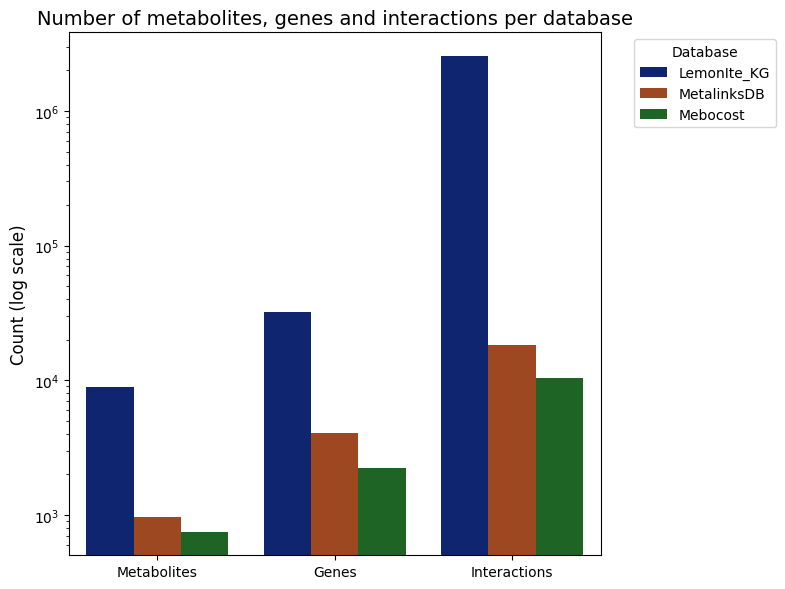

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Melt the DataFrame to long format for grouped bar plot
dat_melted = pd.melt(dat, id_vars="Database", value_vars=["Metabolites", "Genes", "Interactions"], 
                     var_name="Category", value_name="Count")

# Set the color palette similar to the image
custom_palette = sns.color_palette("dark", n_colors=3)

# Create the bar plot with log scale
plt.figure(figsize=(8, 6))
sns.barplot(data=dat_melted, x="Category", y="Count", hue="Database", palette=custom_palette)

# Set log scale for the y-axis
plt.yscale('log')

# Set axis labels and title
plt.xlabel('')
plt.ylabel('Count (log scale)', fontsize=12)

# Set the title and adjust layout
plt.title('Number of metabolites, genes and interactions per database', fontsize=14)

# Place the legend outside of the plot (right side)
plt.legend(title="Database", bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout for tightness
plt.tight_layout()

plt.savefig(COMPARISON_FIGURE, dpi=600, bbox_inches='tight')
print(f'Saved comparison figure to: {COMPARISON_FIGURE}')

# Show the plot
plt.show()


## Heatmap that compares the number of metabolites per class in different databases

In [37]:
# Re-read annotated metabolites for superclass analysis
annotated_mets = pd.read_csv(ANNOTATED_METS_FILE, sep='\t')
print(annotated_mets)
# Keep colums ['HMDB', 'SubClass', 'SuperClass']
annotated_mets = annotated_mets[['HMDB', 'Sub_Class', 'Super_Class']]

                              Name         HMDB    ChEBI    KEGG   PubChem  \
0                1-Methylhistidine  HMDB0000001  50599.0  C01152   92105.0   
1               1,3-Diaminopropane  HMDB0000002  15725.0  C00986     428.0   
2               2-Ketobutyric acid  HMDB0000005  30831.0  C00109      58.0   
3            2-Hydroxybutyric acid  HMDB0000008  50613.0  C05984  440864.0   
4                 2-Methoxyestrone  HMDB0000010   1189.0  C05299  440624.0   
...                            ...          ...      ...     ...       ...   
217915         Nordeoxycholic acid  HMDB0304947      NaN     NaN  314374.0   
217916  3-Oxo-5beta-cholanoic acid  HMDB0304950      NaN     NaN  543448.0   
217917        Glycerol 1-myristate  HMDB0304951  75562.0     NaN   79050.0   
217918       O-Phenolsulfonic acid  HMDB0304953  71049.0     NaN   11867.0   
217919                   d-Fucitol  HMDB0304954      NaN     NaN  445724.0   

                                               IUPAC_Name  \
0 

In [38]:
# Any metabolites from metalinksDB and MEBOCOST that are not in the annotated metabolites?
print(f'Number of metabolites from metalinksDB not in the annotated metabolites: {len(set(metalinks_metabolites) - set(annotated_mets["HMDB"]))}')
print(f'Number of metabolites from MEBOCOST not in the annotated metabolites: {len(set(mebocost_metabolites) - set(annotated_mets["HMDB"]))}')

Number of metabolites from metalinksDB not in the annotated metabolites: 0
Number of metabolites from MEBOCOST not in the annotated metabolites: 0


In [39]:
superclasses = annotated_mets['Super_Class'].unique()
print(f'Number of unique superclasses: {len(superclasses)}')
# initiate df with columns LemonIte_PKN, MetalinksDB, Mebocost + one row for each superclass
dat_superclasses = pd.DataFrame(columns=['LemonIte_KG', 'MetalinksDB', 'Mebocost'], index=superclasses)
# set all values to 0
dat_superclasses = dat_superclasses.fillna(0)
print(dat_superclasses)

Number of unique superclasses: 27
                                           LemonIte_KG  MetalinksDB  Mebocost
Organic acids and derivatives                        0            0         0
Organic nitrogen compounds                           0            0         0
Lipids and lipid-like molecules                      0            0         0
Nucleosides, nucleotides, and analogues              0            0         0
Organoheterocyclic compounds                         0            0         0
Benzenoids                                           0            0         0
Organic oxygen compounds                             0            0         0
Homogeneous non-metal compounds                      0            0         0
Phenylpropanoids and polyketides                     0            0         0
Homogeneous metal compounds                          0            0         0
Alkaloids and derivatives                            0            0         0
Miscellaneous inorganic compou

/tmp/ipykernel_373131/2014123812.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dat_superclasses = dat_superclasses.fillna(0)


In [40]:
superclasses = annotated_mets['Super_Class'].unique()
print(f'Number of unique superclasses: {len(superclasses)}')
# initiate df with columns LemonIte_PKN, MetalinksDB, Mebocost + one row for each superclass
dat_superclasses = pd.DataFrame(columns=['LemonIte_KG', 'MetalinksDB', 'Mebocost'], index=superclasses)
# set all values to 0
dat_superclasses = dat_superclasses.fillna(0)
#print(dat_superclasses)

for hmdb in annotated_mets['HMDB'].tolist():
    # Get the superclass for this metabolite
    #print(hmdb)
    if hmdb in PKN_metabolites:
        superclass = annotated_mets.loc[annotated_mets['HMDB'] == hmdb, 'Super_Class'].values[0]
        dat_superclasses.loc[superclass, 'LemonIte_KG'] += 1
        #print('ok')
        #print(superclass)
    if hmdb in metalinks_metabolites:
        superclass = annotated_mets.loc[annotated_mets['HMDB'] == hmdb, 'Super_Class'].values[0]
        dat_superclasses.loc[superclass, 'MetalinksDB'] += 1
    if hmdb in mebocost_metabolites:
        superclass = annotated_mets.loc[annotated_mets['HMDB'] == hmdb, 'Super_Class'].values[0]
        dat_superclasses.loc[superclass, 'Mebocost'] += 1

print(dat_superclasses)

Number of unique superclasses: 27


/tmp/ipykernel_373131/1413393167.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dat_superclasses = dat_superclasses.fillna(0)


                                           LemonIte_KG  MetalinksDB  Mebocost
Organic acids and derivatives                     1162           79       152
Organic nitrogen compounds                         181           16        19
Lipids and lipid-like molecules                   2179          699       221
Nucleosides, nucleotides, and analogues            251           29        76
Organoheterocyclic compounds                      1894           43        84
Benzenoids                                        1476           15        40
Organic oxygen compounds                           683           53       132
Homogeneous non-metal compounds                     40           11        16
Phenylpropanoids and polyketides                   609           10         5
Homogeneous metal compounds                         19            6         2
Alkaloids and derivatives                          128            1         1
Miscellaneous inorganic compounds                    0          

In [41]:
# Drop rows where the index has NaN values
dat_superclasses = dat_superclasses[~dat_superclasses.index.isna()]
dat_superclasses

,LemonIte_KG,MetalinksDB,Mebocost
Organic acids and derivatives,1162,79,152
Organic nitrogen compounds,181,16,19
Lipids and lipid-like molecules,2179,699,221
"Nucleosides, nucleotides, and analogues",251,29,76
Organoheterocyclic compounds,1894,43,84
Benzenoids,1476,15,40
Organic oxygen compounds,683,53,132
Homogeneous non-metal compounds,40,11,16
Phenylpropanoids and polyketides,609,10,5
Homogeneous metal compounds,19,6,2


In [42]:
dat_superclasses.index

Index(['Organic acids and derivatives', 'Organic nitrogen compounds',
       'Lipids and lipid-like molecules',
       'Nucleosides, nucleotides, and analogues',
       'Organoheterocyclic compounds', 'Benzenoids',
       'Organic oxygen compounds', 'Homogeneous non-metal compounds',
       'Phenylpropanoids and polyketides', 'Homogeneous metal compounds',
       'Alkaloids and derivatives', 'Miscellaneous inorganic compounds',
       'Organosulfur compounds', 'Mixed metal/non-metal compounds',
       'Hydrocarbons', 'Lignans, neolignans and related compounds',
       'Acetylides', 'Organometallic compounds', 'Organic Polymers',
       'Organohalogen compounds', 'Organic 1,3-dipolar compounds',
       'Organic salts', 'Organophosphorus compounds',
       'Hydrocarbon derivatives', 'Allenes', 'Organic compounds'],
      dtype='object')

In [43]:
df = dat_superclasses
# remove rows with only zeros
df = df[(df.T != 0).any()]
#print(df)

# Calculate the percentage of metabolites in each superclass per database
df_percentage = df.div(df.sum(axis=0), axis=1) * 100
print(df_percentage)

                                           LemonIte_KG  MetalinksDB   Mebocost
Organic acids and derivatives                13.177591     8.178054  20.239680
Organic nitrogen compounds                    2.052620     1.656315   2.529960
Lipids and lipid-like molecules              24.710819    72.360248  29.427430
Nucleosides, nucleotides, and analogues       2.846450     3.002070  10.119840
Organoheterocyclic compounds                 21.478793     4.451346  11.185087
Benzenoids                                   16.738489     1.552795   5.326232
Organic oxygen compounds                      7.745521     5.486542  17.576565
Homogeneous non-metal compounds               0.453618     1.138716   2.130493
Phenylpropanoids and polyketides              6.906328     1.035197   0.665779
Homogeneous metal compounds                   0.215468     0.621118   0.266312
Alkaloids and derivatives                     1.451576     0.103520   0.133156
Organosulfur compounds                        0.7371

Saved superclass heatmap to: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/figures/percentage_of_metabolites_in_each_superclass_per_database.png


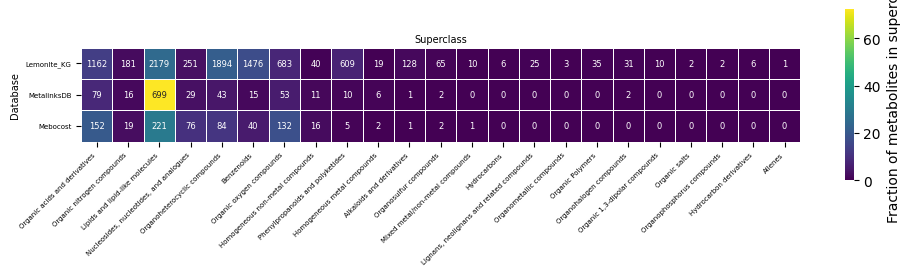

In [44]:
# Create the heatmap
plt.figure(figsize=(10, 6))
# Create the heatmap with transposed data
sns.heatmap(df_percentage.T, annot=df.T, fmt=".0f", cmap='viridis',
            cbar_kws={'label': 'Fraction of metabolites in superclass', 'shrink': 0.3,},
            annot_kws={"fontsize": 6},
            linewidths=0.5, square=True)  # 'square=True' ensures square boxes

# Rotate x-axis labels and place them above the heatmap

#plt.gca().xaxis.set_ticks_position('top')  # Move x-axis ticks to the top
plt.gca().xaxis.set_label_position('top')  # Move x-axis label to the top

plt.xlabel('Superclass', fontsize=7)
plt.ylabel('Database', fontsize=7)
plt.xticks(rotation=45, ha = 'right')
plt.xticks(fontsize=5)
plt.yticks(fontsize=5)


# Adjust layout to prevent overlapping
plt.tight_layout()

plt.savefig(SUPERCLASS_HEATMAP_FIGURE, dpi=600, bbox_inches='tight')
print(f'Saved superclass heatmap to: {SUPERCLASS_HEATMAP_FIGURE}')